In [1]:
# Downgrade version of TensorFlow and tf-keras

!pip install -q --upgrade "tensorflow<2.16" "tf-keras<2.16"

In [2]:
# Import Libraries

import glob
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model

# Check TensorFlow version
print(tf.__version__)

2.15.1


In [3]:
# Load the model
model = tf.keras.models.load_model("model_cnn.h5")

In [4]:
#
img_height = 350
img_width = 350
batch_size = 64

In [5]:
# Making a function to predict and show the prediction result
def prediction(file):
    # Load new data and change the size
    img = tf.keras.utils.load_img(file, target_size=(img_height, img_width))
    x = tf.keras.utils.img_to_array(img) / 255.0  # Normalization

    # Show the image that wanna to test
    plt.imshow(img)
    plt.axis("off")  # Remove the axis
    plt.show()

    # Adding batch dimension
    x = np.expand_dims(x, axis=0)

    # Predict with model
    y_pred_proba = model.predict(x)[0][0] # Get scalar probality instead of array


    # Condition for the prediction result
    if y_pred_proba >= 0.5:
        y_pred_class = 1  # For negative class ('WildFire')
    else:
        y_pred_class = 0  # For positive class ('NoWildfire')

    # Get class names based on prediction result
    class_names = ['nowildfire', 'wildfire']  # 0=nowildfire, 1=wildfire
    y_pred_class_name = class_names[y_pred_class]

    # Sho the prediction result
    print(f"Prediction: {y_pred_class_name} (Confidence: {y_pred_proba})")

--2025-02-06 14:59:29--  https://www.zerogravity.fi/wp-content/uploads/2019/11/satellite-data-e1572891876593-621x556.jpg
Resolving www.zerogravity.fi (www.zerogravity.fi)... 188.165.140.194
Connecting to www.zerogravity.fi (www.zerogravity.fi)|188.165.140.194|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 148311 (145K) [image/jpeg]
Saving to: ‘image_inference_1.jpg’

image_inference_1.j 100%[===================>] 144.83K   330KB/s    in 0.4s    

2025-02-06 14:59:30 (330 KB/s) - ‘image_inference_1.jpg’ saved [148311/148311]



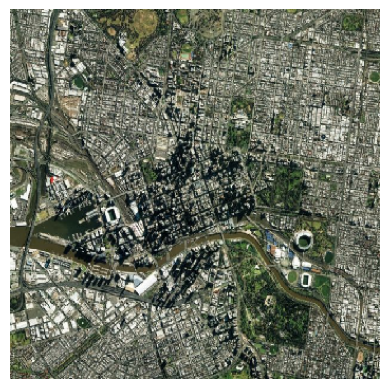

1/1 [==============================] - 0s 286ms/step
Prediction: nowildfire (Confidence: 5.637325675711402e-12)


In [6]:
# Download a new image
!wget https://www.zerogravity.fi/wp-content/uploads/2019/11/satellite-data-e1572891876593-621x556.jpg -O image_inference_1.jpg

# Inferencing
prediction('image_inference_1.jpg')